<a href="https://colab.research.google.com/github/stepanmouratoglou-a11y/Premier-League-Predictions/blob/main/PremierLeague.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Importing the dataset & Feature Engineering**
##### Here , I am creating some new categories such as

*I drop some columns that will not help on predicting future outcomes , such as Division,Home and Away Red Cards and finally the **time** that the match took place*


*   Average Goals **scored** from the last 5 games
*   Average Goals **conceded** from the last 5 games
*   Average shots from the last 5 games
* Average shots **conceded** from the last 5 games
* Respectively for the shots **on target** from the last 5 games
* Average corners made last 5 games
* Average corners **conceded** last 5 games
* Wins last 5 games
* Losses Last 5 games
* Draws Last 5 games


Also, I create a DataFrame which I turn into csv , to visualize all the data and the analytics at the EDA.ipynb file

In [2]:
dataset=pd.read_csv('E0 (1).csv').iloc[:,:24]

dataset=dataset.drop(columns=['Div','HR','AR','Time','Referee'])

dataset['Date'] = pd.to_datetime(dataset['Date'], format='%d/%m/%Y')
dataset['Month']=dataset['Date'].dt.month
dataset['Day']=dataset['Date'].dt.dayofweek

home_matches=dataset[['Date','HomeTeam']].rename(columns={'HomeTeam':'Team'})
away_matches=dataset[['Date','AwayTeam']].rename(columns={'AwayTeam':'Team'})

matches=pd.concat((home_matches,away_matches)).sort_values(['Team','Date'])

matches['Days_Rest']=matches.groupby('Team')['Date'].diff().dt.days
matches['Days_Rest']=matches['Days_Rest'].fillna(15)

dataset=dataset.merge(matches, left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
dataset=dataset.rename(columns={'Days_Rest': 'Home_Days_Rest'}).drop(columns=['Team'])

dataset=dataset.merge(matches, left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
dataset=dataset.rename(columns={'Days_Rest': 'Away_Days_Rest'}).drop(columns=['Team'])

dataset=dataset.sort_values('Date').reset_index(drop=True)


home_stats = dataset[['Date', 'HomeTeam', 'FTHG', 'FTAG','HS','AS','HST',
                      'AST','HC','AC','HF','AF','HY','AY']].copy()
home_stats = home_stats.rename(columns={
    'HomeTeam':'Team',
    'FTHG':'Scored',
    'FTAG':'Conceded',
    'HS':'Shots_made',
    'AS':'Shots_Conceded',
    'HST':'Shots_ontarget_made',
    'AST':'Shots_ontarget_conceded',
    'HC':'Corners_made',
    'AC':'Corners_conceded',
    'HF':'Fouls_commited',
    'AF':'Fouls_suffered',
    'HY':'Yellow_Cards',
    'AY':'Opposing_Yellow_Cards'
})
home_stats['Wins']= (dataset['FTR']=='H').astype(int)
home_stats['Draws']=(dataset['FTR']=='D').astype(int)
home_stats['Losses']=(dataset['FTR']=='A').astype(int)

away_stats = dataset[['Date','AwayTeam','FTAG','FTHG','HS','AS','HST',
                      'AST','HC','AC','HF','AF','HY','AY']].copy()
away_stats = away_stats.rename(columns={
    'AwayTeam':'Team',
    'FTAG':'Scored',
    'FTHG':'Conceded',
    'HS':'Shots_Conceded',#This does not refer to the goals conceded , it contains the amount of all shots against the team
    'AS':'Shots_made',
    'HST':'Shots_ontarget_conceded',
    'AST':'Shots_ontarget_made',
    'HC':'Corners_conceded',#This does not refer to the goals conceded from corners , but the amount of corners the opposing team got
    'AC':'Corners_made',
    'HF':'Fouls_suffered',
    'AF':'Fouls_commited',
    'HY':'Opposing_Yellow_Cards',
    'AY':'Yellow_Cards'
})

away_stats['Wins']=(dataset['FTR']=='A').astype(int)
away_stats['Draws']=(dataset['FTR']=='D').astype(int)
away_stats['Losses']=(dataset['FTR']=='H').astype(int)

all_stats=pd.concat([home_stats,away_stats])
team_performance=all_stats.drop(columns=['Date']).groupby('Team').sum().reset_index()
total_games=team_performance['Wins']+team_performance['Draws']+team_performance['Losses']


team_performance['Goal_Difference']=team_performance['Scored']-team_performance['Conceded']
team_performance['Shots_Per_Game']=team_performance['Shots_made']/total_games
team_performance['Corners_Per_Game']=team_performance['Corners_made']/total_games
team_performance['SoT_Per_Game']=team_performance['Shots_ontarget_made']/total_games
team_performance['Goals_Per_Game']=team_performance['Scored']/total_games
team_performance['Goals_Conceded_Per_Game']=team_performance['Conceded']/total_games
team_performance['Fouls_commited_Per_Game']=team_performance['Fouls_commited']/total_games
team_performance['Shots_Conceded_Per_Game']=team_performance['Shots_Conceded']/total_games
team_performance['Yellow_Cards_Per_Game']=team_performance['Yellow_Cards']/total_games

team_stats = pd.concat([home_stats, away_stats]).sort_values(['Team', 'Date']).reset_index(drop=True)


team_stats['Avg_Scored_Last_5'] = team_stats.groupby('Team')['Scored'].\
transform(lambda x: x.shift(1).rolling(window=5).mean())
team_stats['Avg_Conceded_Last_5'] = team_stats.groupby('Team')['Conceded'].\
transform(lambda x: x.shift(1).rolling(window=5).mean())

team_stats['Wins_Last_5']=team_stats.groupby('Team')['Wins'].transform\
 (lambda x: x.shift(1).rolling(window=5).sum())
team_stats['Losses_Last_5']=team_stats.groupby('Team')['Losses'].transform\
 (lambda x:x.shift(1).rolling(window=5).sum())
team_stats['Draws_Last_5']=team_stats.groupby('Team')['Draws'].transform\
 (lambda x: x.shift(1).rolling(window=5).sum())

team_stats['Avg_Shots_Last_5']=team_stats.groupby('Team')['Shots_made'].transform\
 (lambda x: x.shift(1).rolling(window=5).mean())
team_stats['Avg_Shots_Conceded_Last_5']=team_stats.groupby('Team')['Shots_Conceded'].transform\
 (lambda x: x.shift(1).rolling(window=5).mean())

team_stats['Avg_shots_ontarget_Last_5']=team_stats.groupby('Team')['Shots_ontarget_made'].\
transform(lambda x: x.shift(1).rolling(window=5).mean())
team_stats['Avg_shots_ontarget_Conceded_Last_5']=team_stats.groupby('Team')['Shots_ontarget_conceded'].\
transform(lambda x: x.shift(1).rolling(window=5).mean())

team_stats['Avg_corners_Last_5']=team_stats.groupby('Team')['Corners_made'].transform\
 (lambda x: x.shift(1).rolling(window=5).mean())
team_stats['Avg_corners_conceded_Last_5']=team_stats.groupby('Team')['Corners_conceded'].transform\
 (lambda x: x.shift(1).rolling(window=5).mean())

team_stats=team_stats.fillna(0)

dataset=dataset.merge(
    team_stats[['Date', 'Team', 'Avg_Scored_Last_5', 'Avg_Conceded_Last_5','Avg_Shots_Last_5',
                'Avg_Shots_Conceded_Last_5',
                'Wins_Last_5',
                'Losses_Last_5']],
    left_on=['Date', 'HomeTeam'],
    right_on=['Date', 'Team'],
    how='left'
).rename(columns={
    'Avg_Scored_Last_5': 'Home_Avg_Scored_5',
    'Avg_Conceded_Last_5': 'Home_Avg_Conceded_5',
    'Avg_Shots_Last_5':'Home_Avg_Shots_Last_5',
    'Avg_Shots_Conceded_Last_5':'Home_Avg_Shots_Conceded_Last_5',
    'Wins_Last_5':'Home_Wins_Last_5',
    'Losses_Last_5':'Home_Losses_Last_5'
}).drop(columns=['Team'])

dataset=dataset.merge(
    team_stats[['Date', 'Team', 'Avg_Scored_Last_5', 'Avg_Conceded_Last_5','Avg_Shots_Last_5',
                'Avg_Shots_Conceded_Last_5',
                'Wins_Last_5',
                'Losses_Last_5']],
    left_on=['Date', 'AwayTeam'],
    right_on=['Date', 'Team'],
    how='left'
).rename(columns={
    'Avg_Scored_Last_5': 'Away_Avg_Scored_5',
    'Avg_Conceded_Last_5': 'Away_Avg_Conceded_5',
    'Avg_Shots_Last_5':'Away_Avg_Shots_Last_5',
    'Avg_Shots_Conceded_Last_5':'Away_Avg_Shots_Conceded_Last_5',
    'Wins_Last_5':'Away_Wins_Last_5',
    'Losses_Last_5':'Away_Losses_Last_5'
}).drop(columns=['Team'])


## **Calculating ELO Rating**

In [3]:
def expected_probability(elo_a,elo_b):
  return 1/(1+10**((elo_b-elo_a)/400))

In [4]:
def elo_rating(elo_a,expected_probability,result,K=20):
  return elo_a+K*(result-expected_probability)

In [5]:
def k_Calculation(team_elo,matches_played):
  if matches_played>10:
    return 35
  elif team_elo>1900:
    return 10
  else:
    return 20

## **Importing the dataset again after feature engineering.**
*More specifically , I remove the **Date** column , as the column was formatted better at the step above*.

*Also , I remove the categories "FullTime Away Goals" ,"FullTime Home Goals", "Home Scored", "Away Scored" to avoid **Data Leakage***

Note:These categories are not important now, as new categories were created above eg."Average goals last 5 games"

In [6]:
team_performance.head()

,Team,Scored,Conceded,Shots_made,Shots_Conceded,Shots_ontarget_made,Shots_ontarget_conceded,Corners_made,Corners_conceded,Fouls_commited,...,Losses,Goal_Difference,Shots_Per_Game,Corners_Per_Game,SoT_Per_Game,Goals_Per_Game,Goals_Conceded_Per_Game,Fouls_commited_Per_Game,Shots_Conceded_Per_Game,Yellow_Cards_Per_Game
0,Arsenal,61,22,454,242,153,72,181,103,316,...,3,39,14.645161,5.838710,4.935484,1.967742,0.709677,10.193548,7.806452,1.290323
1,Aston Villa,42,37,397,395,135,132,166,148,310,...,9,5,12.806452,5.354839,4.354839,1.354839,1.193548,10.000000,12.741935,1.516129
2,Bournemouth,46,48,435,393,149,140,177,165,367,...,7,-2,14.032258,5.709677,4.806452,1.483871,1.548387,11.838710,12.677419,2.290323
3,Brentford,46,42,320,390,122,122,148,157,329,...,11,4,10.322581,4.774194,3.935484,1.483871,1.354839,10.612903,12.580645,1.870968
4,Brighton,41,37,398,378,138,122,147,150,374,...,10,4,12.838710,4.741935,4.451613,1.322581,1.193548,12.064516,12.193548,2.548387


## **ELO Rating Pipeline**

In [7]:
teams_elo={
    'Man City':1941,
    'Liverpool':1926,
    'Arsenal':2061,
    'Aston Villa':1885,
    'Brighton':1844,
    'Sunderland':1500,
    'Tottenham':1760,
    'Wolves':1640,
    'Nott\'m Forest':1575,
    'Man United':1881,
    'Leeds':1500,
    'Everton':1600,
    'Bournemouth':1750,
    'Newcastle':1800,
    'Chelsea':1869,
    'West Ham':1690,
    'Fulham':1750,
    'Crystal Palace':1800,
    'Burnley':1500
}
default_elo=1500
home_elo=[]
away_elo=[]
matches_played={}

for index,row in dataset.iterrows():
  home_team=row['HomeTeam']
  away_team=row['AwayTeam']
  result=row['FTR']

  if home_team not in matches_played:
    matches_played[home_team]=0
  if away_team not in matches_played:
    matches_played[away_team]=0

  if home_team not in teams_elo:
    teams_elo[home_team]=default_elo
    matches_played[home_team]=0
  if away_team not in teams_elo:
    teams_elo[away_team]=default_elo
    matches_played[away_team]=0

  current_home_elo=teams_elo[home_team]
  current_away_elo=teams_elo[away_team]
  home_elo.append(current_home_elo)
  away_elo.append(current_away_elo)

  expected_home_elo=expected_probability(current_home_elo,current_away_elo)
  expected_away_elo=expected_probability(current_away_elo,current_home_elo)

  if result=='H':
    home_result,away_result=1,0
  elif result=='D':
    home_result,away_result=0.5,0.5
  else:
    home_result,away_result=0,1

  home_k=k_Calculation(current_home_elo,matches_played[home_team])
  away_k=k_Calculation(current_away_elo,matches_played[away_team])

  teams_elo[home_team]=elo_rating(current_home_elo,expected_home_elo,home_result,home_k)
  teams_elo[away_team]=elo_rating(current_away_elo,expected_away_elo,away_result,away_k)

  matches_played[home_team]+=1
  matches_played[away_team]+=1

dataset['Home_ELO_Score']=home_elo
dataset['Away_ELO_Score']=away_elo


In [8]:
dataset=dataset.sort_values('Date')
dataset=dataset.drop(columns=['Date','FTAG','FTHG','HTR','HS','AS','Day','Month','HY','AY',
                              'HTHG','HTAG','HST','AST','HF','AF','HC','AC'])
X=dataset.drop(columns=['FTR']).values
y=dataset['FTR'].values

In [9]:
dataset.head()

,HomeTeam,AwayTeam,FTR,Home_Days_Rest,Away_Days_Rest,Home_Avg_Scored_5,Home_Avg_Conceded_5,Home_Avg_Shots_Last_5,Home_Avg_Shots_Conceded_Last_5,Home_Wins_Last_5,Home_Losses_Last_5,Away_Avg_Scored_5,Away_Avg_Conceded_5,Away_Avg_Shots_Last_5,Away_Avg_Shots_Conceded_Last_5,Away_Wins_Last_5,Away_Losses_Last_5,Home_ELO_Score,Away_ELO_Score
0,Liverpool,Bournemouth,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1926.0,1750.0
1,Aston Villa,Newcastle,D,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1885.0,1800.0
2,Brighton,Fulham,D,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1844.0,1750.0
3,Sunderland,West Ham,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1690.0
4,Tottenham,Burnley,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1760.0,1500.0


In [10]:
dataset.shape

(309, 19)

## **Checking for missing values**

In [11]:
indep_cols=dataset.iloc[:,:-1]
missing_values=list(dataset.columns.get_loc(cols) for cols in indep_cols if dataset[cols].isnull().sum()>0 )

In [12]:
print(missing_values)

[]


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 309 entries, 0 to 308
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   HomeTeam                        309 non-null    object 
 1   AwayTeam                        309 non-null    object 
 2   FTR                             309 non-null    object 
 3   Home_Days_Rest                  309 non-null    float64
 4   Away_Days_Rest                  309 non-null    float64
 5   Home_Avg_Scored_5               309 non-null    float64
 6   Home_Avg_Conceded_5             309 non-null    float64
 7   Home_Avg_Shots_Last_5           309 non-null    float64
 8   Home_Avg_Shots_Conceded_Last_5  309 non-null    float64
 9   Home_Wins_Last_5                309 non-null    float64
 10  Home_Losses_Last_5              309 non-null    float64
 11  Away_Avg_Scored_5               309 non-null    float64
 12  Away_Avg_Conceded_5             309 non-n

## **Saving the categorical feature's indexes to apply Target Encoding Later**

In [14]:
categorical_features=[]
for cols in dataset.columns:
  if cols=='FTR':
    continue
  if dataset[cols].dtype =='object':
    categorical_features.append(dataset.columns.get_loc(cols))
print(categorical_features)

[0, 1]


In [15]:
print(y)

['H' 'D' 'D' 'H' 'H' 'A' 'D' 'H' 'A' 'H' 'A' 'A' 'H' 'H' 'H' 'H' 'D' 'H'
 'D' 'A' 'H' 'H' 'H' 'A' 'A' 'D' 'H' 'A' 'H' 'A' 'A' 'D' 'H' 'H' 'D' 'D'
 'H' 'H' 'A' 'H' 'H' 'D' 'D' 'A' 'A' 'H' 'H' 'D' 'D' 'D' 'H' 'A' 'H' 'D'
 'H' 'A' 'D' 'H' 'A' 'D' 'H' 'A' 'H' 'H' 'H' 'H' 'H' 'H' 'D' 'A' 'A' 'H'
 'A' 'H' 'H' 'H' 'D' 'A' 'A' 'A' 'H' 'A' 'H' 'H' 'H' 'H' 'H' 'H' 'A' 'A'
 'H' 'A' 'H' 'H' 'D' 'A' 'H' 'H' 'H' 'D' 'D' 'H' 'H' 'D' 'H' 'H' 'D' 'H'
 'H' 'H' 'A' 'D' 'H' 'H' 'A' 'A' 'H' 'A' 'H' 'A' 'H' 'H' 'H' 'A' 'A' 'A'
 'H' 'A' 'A' 'D' 'A' 'A' 'D' 'A' 'A' 'H' 'A' 'D' 'H' 'D' 'H' 'D' 'H' 'H'
 'H' 'D' 'H' 'D' 'A' 'A' 'H' 'H' 'A' 'H' 'H' 'H' 'D' 'A' 'A' 'D' 'D' 'D'
 'D' 'H' 'A' 'A' 'A' 'H' 'H' 'H' 'H' 'A' 'H' 'A' 'H' 'H' 'A' 'D' 'D' 'A'
 'A' 'D' 'A' 'D' 'H' 'D' 'D' 'D' 'D' 'D' 'H' 'H' 'H' 'A' 'D' 'H' 'A' 'D'
 'D' 'D' 'A' 'H' 'H' 'D' 'D' 'H' 'D' 'D' 'H' 'D' 'H' 'H' 'H' 'H' 'A' 'D'
 'D' 'D' 'A' 'D' 'D' 'H' 'H' 'H' 'H' 'A' 'A' 'A' 'A' 'D' 'D' 'A' 'A' 'H'
 'H' 'A' 'H' 'D' 'D' 'H' 'H' 'A' 'H' 'D' 'A' 'A' 'A

## **Applying Label Encoding on the depentent variable - y**
* Before this , the y-dependent variable has values:
"H" for Home win,
"A" for Away win,
"D" for a Draw

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [17]:
print(y)

[2 1 1 2 2 0 1 2 0 2 0 0 2 2 2 2 1 2 1 0 2 2 2 0 0 1 2 0 2 0 0 1 2 2 1 1 2
 2 0 2 2 1 1 0 0 2 2 1 1 1 2 0 2 1 2 0 1 2 0 1 2 0 2 2 2 2 2 2 1 0 0 2 0 2
 2 2 1 0 0 0 2 0 2 2 2 2 2 2 0 0 2 0 2 2 1 0 2 2 2 1 1 2 2 1 2 2 1 2 2 2 0
 1 2 2 0 0 2 0 2 0 2 2 2 0 0 0 2 0 0 1 0 0 1 0 0 2 0 1 2 1 2 1 2 2 2 1 2 1
 0 0 2 2 0 2 2 2 1 0 0 1 1 1 1 2 0 0 0 2 2 2 2 0 2 0 2 2 0 1 1 0 0 1 0 1 2
 1 1 1 1 1 2 2 2 0 1 2 0 1 1 1 0 2 2 1 1 2 1 1 2 1 2 2 2 2 0 1 1 1 0 1 1 2
 2 2 2 0 0 0 0 1 1 0 0 2 2 0 2 1 1 2 2 0 2 1 0 0 0 2 0 0 1 0 0 1 2 0 2 1 0
 1 1 1 0 2 1 1 0 0 2 0 0 2 1 0 2 0 0 2 2 2 2 1 2 0 2 0 2 0 1 0 0 1 0 2 0 1
 2 1 1 1 1 1 2 2 2 1 0 2 0]


## **Initializing the training and test set**

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [19]:
print(X_test)

[['Arsenal' 'Sunderland' 7.0 ... 2.0 2014.727988312895 1648.1393494893562]
 ['Brighton' 'Crystal Palace' 8.0 ... 3.0 1768.6988452974088
  1709.6370518861283]
 ['Liverpool' 'Man City' 8.0 ... 1.0 1859.5472022121824
  1899.4418046659287]
 ...
 ['Newcastle' 'Sunderland' 8.0 ... 3.0 1770.4684076155659
  1636.8552357777512]
 ['Aston Villa' 'West Ham' 7.0 ... 1.0 1816.165396735817
  1691.770139074737]
 ['Tottenham' "Nott'm Forest" 7.0 ... 2.0 1643.6762176871464
  1621.8006953663867]]


# After applying Label Encoding, the y-dependent variable changed:
#### **Home Win = 2**
#### **Away Win = 0**
#### **Draw = 1**


In [20]:
print(y_test)

[2 0 0 1 0 0 1 2 0 2 1 0 1 1 1 0 2 1 1 0 0 2 0 0 2 1 0 2 0 0 2 2 2 2 1 2 0
 2 0 2 0 1 0 0 1 0 2 0 1 2 1 1 1 1 1 2 2 2 1 0 2 0]


In [21]:
for i in range(len(X_test)):
  if y_test[i]==0:
    outcome=X_test[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test[i][0]
  print(X_test[i][0]+ " vs "+X_test[i][1] +" = " + outcome)

Arsenal vs Sunderland = Arsenal
Brighton vs Crystal Palace = Crystal Palace
Liverpool vs Man City = Man City
Chelsea vs Leeds = Draw
Everton vs Bournemouth = Bournemouth
Tottenham vs Newcastle = Newcastle
West Ham vs Man United = Draw
Aston Villa vs Brighton = Aston Villa
Crystal Palace vs Burnley = Burnley
Man City vs Fulham = Man City
Nott'm Forest vs Wolves = Draw
Sunderland vs Liverpool = Liverpool
Brentford vs Arsenal = Draw
Wolves vs Arsenal = Draw
Chelsea vs Burnley = Draw
Brentford vs Brighton = Brighton
Man City vs Newcastle = Man City
West Ham vs Bournemouth = Draw
Aston Villa vs Leeds = Draw
Nott'm Forest vs Liverpool = Liverpool
Sunderland vs Fulham = Fulham
Crystal Palace vs Wolves = Crystal Palace
Tottenham vs Arsenal = Arsenal
Everton vs Man United = Man United
Wolves vs Aston Villa = Wolves
Bournemouth vs Sunderland = Draw
Burnley vs Brentford = Brentford
Liverpool vs West Ham = Liverpool
Newcastle vs Everton = Everton
Leeds vs Man City = Man City
Brighton vs Nott'm For

In [22]:
X_test_copy=X_test.copy()
y_test_copy=y_test.copy()

## **Removing the HomeTeam and AwayTeam from the train and test set**
#### The rolew of the HomeTeam and AwayTeam, might lead to data leakage.So that is why I calculated the ELO rating of each team , so that the predictions are bases on the ELO ratings , not the club's name

In [23]:
X_train=X_train[:,2:]
X_test=X_test[:,2:]

## **This Function filters the predictions that have a big chance of draw**

In [43]:
def draw_filter(model):
  DRAW_THRESHOLD=0.3
  DRAW_PENALTY=0.5
  HOME_AWAY_BONUS=0.25

  filtered=model.copy()

  for i in range(len(filtered)):
    p_home=filtered[i][2]
    p_away=filtered[i][0]
    p_draw=filtered[i][1]

    if p_draw>=DRAW_THRESHOLD:
      filtered[i][1]=p_draw*DRAW_PENALTY
      filtered[i][0]+=p_draw*HOME_AWAY_BONUS
      filtered[i][2]+=p_draw*HOME_AWAY_BONUS
  return filtered

## **Random Forest Classification**


In [25]:
from sklearn.ensemble import RandomForestClassifier
weights={2:1.8,1:0.4,0:1.6}
rf_classifier=RandomForestClassifier(criterion='gini',class_weight=weights)

## **Applying GridSearchCV for the RF model**

In [26]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
tscv=TimeSeriesSplit(n_splits=5)
parameters = {
    'n_estimators':[75,100,150],
    'max_features':['sqrt','log2']
}
grid_search=GridSearchCV(estimator=rf_classifier,
                         param_grid=parameters,verbose=2,
                         n_jobs=-1,
                         scoring='accuracy')

grid_search.fit(X_train,y_train)
print("Best accuracy for RF Classifier found: {:.2f} %".format(grid_search.best_score_*100))
print("Best parameters for RF Classifier: ",grid_search.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best accuracy for RF Classifier found: 42.08 %
Best parameters for RF Classifier:  {'max_features': 'sqrt', 'n_estimators': 150}


### **The *detector_rf* model, is used to help us remove the features with low importance**

In [27]:
detector_rf=RandomForestClassifier(criterion='gini',
                                     max_features='sqrt',
                                     n_estimators=150,
                                     class_weight=weights
                                     )

In [28]:
detector_rf.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: 1.6, 1: 0.4, 2: 1.8}, n_estimators=150)

In [29]:
importances_rf=detector_rf.feature_importances_

In [30]:
print(X_train.shape)

(247, 16)


In [31]:
print(X_test.shape)

(62, 16)


## **Applying the *SelectFromModel* feature to remove features that are less important for the model**

In [32]:
from sklearn.feature_selection import SelectFromModel
selector=SelectFromModel(detector_rf,threshold=0.04)
X_train_rf=selector.fit_transform(X_train,y_train)
X_test_rf=selector.transform(X_test)
rf_classifier=RandomForestClassifier(criterion='gini',
                                     class_weight=weights,
                                     max_features='sqrt',
                                     n_estimators=150
                                    )
rf_classifier.fit(X_train_rf,y_train)

RandomForestClassifier(class_weight={0: 1.6, 1: 0.4, 2: 1.8}, n_estimators=150)

In [33]:
print(X_train_rf.shape)

(247, 10)


In [34]:
print(X_test_rf.shape)

(62, 10)


In [35]:
print(importances_rf)

[0.07488755 0.05509124 0.05040556 0.0444352  0.0747231  0.06436379
 0.02644189 0.0350482  0.04900226 0.03969263 0.05716694 0.05935737
 0.03274835 0.02289711 0.16076021 0.1529786 ]


In [36]:
print(dataset.drop(columns=['HomeTeam','AwayTeam','FTR']).columns)

Index(['Home_Days_Rest', 'Away_Days_Rest', 'Home_Avg_Scored_5',
       'Home_Avg_Conceded_5', 'Home_Avg_Shots_Last_5',
       'Home_Avg_Shots_Conceded_Last_5', 'Home_Wins_Last_5',
       'Home_Losses_Last_5', 'Away_Avg_Scored_5', 'Away_Avg_Conceded_5',
       'Away_Avg_Shots_Last_5', 'Away_Avg_Shots_Conceded_Last_5',
       'Away_Wins_Last_5', 'Away_Losses_Last_5', 'Home_ELO_Score',
       'Away_ELO_Score'],
      dtype='object')


In [37]:
f_importances=pd.DataFrame({
    'Feature':list(dataset.drop(columns=['HomeTeam','AwayTeam','FTR']).columns),
    'Importances':(importances_rf*100).astype(float).round(2)
}).sort_values(by='Importances',ascending=False)

In [38]:
f_importances.head()

,Feature,Importances
14,Home_ELO_Score,16.08
15,Away_ELO_Score,15.30
0,Home_Days_Rest,7.49
4,Home_Avg_Shots_Last_5,7.47
5,Home_Avg_Shots_Conceded_Last_5,6.44


## **Feature Importance Visualization**

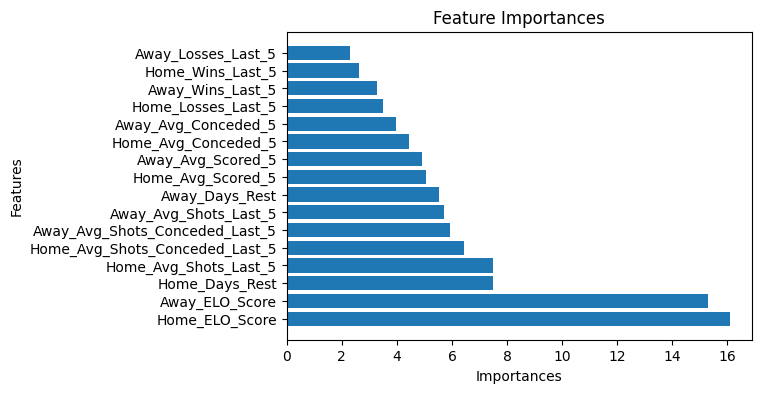

In [39]:
plt.figure(figsize=(6,4))
plt.barh(width=f_importances['Importances'],y=f_importances['Feature'])
plt.xlabel("Importances")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [40]:
y_pred=rf_classifier.predict_proba(X_test_rf)

## **Filtering the Predictions of RF Classifier**
#### More specifically, the matches where "Draw" is predicted in a very high perfentage.In the real, and the betting world Draws never tend to be the favourite of a football game

In [44]:
y_pred=draw_filter(y_pred)

## **Printing the Results and the Predictions after filtering Draw predictions**

In [45]:
for i in range(len(X_test)):
  print(f'===== Predictions for {X_test_copy[i][0]} vs {X_test_copy[i][1]} =====')
  print(X_test_copy[i][0]," Probability to win: {:.2f} %".format(y_pred[i,2]*100))
  print(X_test_copy[i][1]," Probability to win: {:.2f} %".format(y_pred[i,0]*100))
  print("Draw: {:.2f}% ".format(y_pred[i,1]*100))
  if y_test[i]==0:
    outcome=X_test_copy[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test_copy[i][0]
  print(f"Outcome: {outcome}")
  print("\n"*2)

===== Predictions for Arsenal vs Sunderland =====
Arsenal  Probability to win: 81.33 %
Sunderland  Probability to win: 14.00 %
Draw: 4.67% 
Outcome: Arsenal



===== Predictions for Brighton vs Crystal Palace =====
Brighton  Probability to win: 45.33 %
Crystal Palace  Probability to win: 32.00 %
Draw: 22.67% 
Outcome: Crystal Palace



===== Predictions for Liverpool vs Man City =====
Liverpool  Probability to win: 38.00 %
Man City  Probability to win: 36.00 %
Draw: 26.00% 
Outcome: Man City



===== Predictions for Chelsea vs Leeds =====
Chelsea  Probability to win: 53.50 %
Leeds  Probability to win: 28.83 %
Draw: 17.67% 
Outcome: Draw



===== Predictions for Everton vs Bournemouth =====
Everton  Probability to win: 41.67 %
Bournemouth  Probability to win: 39.00 %
Draw: 19.33% 
Outcome: Bournemouth



===== Predictions for Tottenham vs Newcastle =====
Tottenham  Probability to win: 51.00 %
Newcastle  Probability to win: 31.00 %
Draw: 18.00% 
Outcome: Newcastle



===== Predictions fo

## **XGBoost Classifier**

In [46]:
from xgboost import XGBClassifier
classifier=XGBClassifier(learning_rate=0.01)

In [47]:
from sklearn.utils.class_weight import compute_sample_weight
class_weights={0:1.5,1:0.6,2:1.5}
sample_weights=compute_sample_weight(class_weight=class_weights,y=y_train)

In [48]:
xg_parameters={
    'n_estimators':[150,200,300,400,500],
    'colsample_bytree':[0.8,1]
}
grid_search_xg=GridSearchCV(estimator=classifier,
                            param_grid=xg_parameters,
                            n_jobs=-1,
                            verbose=2,
                            scoring='accuracy')
grid_search_xg.fit(X_train,y_train)
print("Best accuracy for Calibrated XGB : {:.2f}%".format(grid_search_xg.best_score_*100))
print("Best parameters for Calibrated XGB Classifier: ",grid_search_xg.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best accuracy for Calibrated XGB : 39.27%
Best parameters for Calibrated XGB Classifier:  {'colsample_bytree': 0.8, 'n_estimators': 500}


In [49]:
classifier=XGBClassifier(colsample_bytree=0.8,
                         learning_rate=0.01,
                         n_estimators=500,
                         )
classifier.fit(X=X_train_rf,y=y_train,sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
y_pred_XG=classifier.predict_proba(X_test_rf)

## **Filtering the Predictions of XGBoost Classifier**
#### More specifically, the matches where "Draw" is predicted in a very high perfentage.In the real and betting world, Draws never tend to be the favourite of a football game

In [51]:
y_pred_XG=draw_filter(y_pred_XG)

In [52]:
for i in range(len(X_test)):
  print(f'===== Predictions for {X_test_copy[i][0]} vs {X_test_copy[i][1]} =====')
  print(X_test_copy[i][0]," Probability to win: {:.2f} %".format(y_pred_XG[i,2]*100))
  print(X_test_copy[i][1]," Probability to win: {:.2f} %".format(y_pred_XG[i,0]*100))
  print("Draw: {:.2f}% ".format(y_pred_XG[i,1]*100))
  if y_test[i]==0:
    outcome=X_test_copy[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test_copy[i][0]
  print(f"Outcome: {outcome}")
  print("\n"*2)

===== Predictions for Arsenal vs Sunderland =====
Arsenal  Probability to win: 89.80 %
Sunderland  Probability to win: 7.77 %
Draw: 2.43% 
Outcome: Arsenal



===== Predictions for Brighton vs Crystal Palace =====
Brighton  Probability to win: 53.93 %
Crystal Palace  Probability to win: 27.44 %
Draw: 18.64% 
Outcome: Crystal Palace



===== Predictions for Liverpool vs Man City =====
Liverpool  Probability to win: 30.05 %
Man City  Probability to win: 47.15 %
Draw: 22.79% 
Outcome: Man City



===== Predictions for Chelsea vs Leeds =====
Chelsea  Probability to win: 58.05 %
Leeds  Probability to win: 30.54 %
Draw: 11.41% 
Outcome: Draw



===== Predictions for Everton vs Bournemouth =====
Everton  Probability to win: 41.51 %
Bournemouth  Probability to win: 41.78 %
Draw: 16.71% 
Outcome: Bournemouth



===== Predictions for Tottenham vs Newcastle =====
Tottenham  Probability to win: 63.42 %
Newcastle  Probability to win: 17.32 %
Draw: 19.26% 
Outcome: Newcastle



===== Predictions for

In [53]:
final_rf_pred=np.argmax(y_pred,axis=1)
final_XG_pred=np.argmax(y_pred_XG,axis=1)

## **Making the Confusion Matrix and the Accuracy Score**

In [54]:
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix of the RandomForest Classifier Model")
print(confusion_matrix(y_test,final_rf_pred))
print(classification_report(y_test,final_rf_pred, zero_division=0))

print()
print("Confusion Matrix of the XGBoost Classifier Model")
print(confusion_matrix(y_test,final_XG_pred))
print(classification_report(y_test,final_XG_pred, zero_division=0))


Confusion Matrix of the RandomForest Classifier Model
[[ 9  0 14]
 [ 7  0 12]
 [ 5  0 15]]
              precision    recall  f1-score   support

           0       0.43      0.39      0.41        23
           1       0.00      0.00      0.00        19
           2       0.37      0.75      0.49        20

    accuracy                           0.39        62
   macro avg       0.26      0.38      0.30        62
weighted avg       0.28      0.39      0.31        62


Confusion Matrix of the XGBoost Classifier Model
[[11  0 12]
 [ 8  0 11]
 [ 5  0 15]]
              precision    recall  f1-score   support

           0       0.46      0.48      0.47        23
           1       0.00      0.00      0.00        19
           2       0.39      0.75      0.52        20

    accuracy                           0.42        62
   macro avg       0.28      0.41      0.33        62
weighted avg       0.30      0.42      0.34        62



## **Applying k-Fold Cross Validation with StratifiedKFold**

In [55]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
skf=StratifiedKFold(n_splits=5)
accuracy_rf=cross_val_score(estimator=rf_classifier,X=X_train,y=y_train,cv=skf)
print("Cross Validation Scores of RF Model: {}".format(accuracy_rf))
print("Mean Accuracy of Random Forest Classifier: {:.2f} %".format(accuracy_rf.mean()*100))
print("Standard Deviation of RF Classifier: {:.2f} %".format(accuracy_rf.std()*100))
print()
accuracy_XG=cross_val_score(estimator=classifier,X=X_train,y=y_train,cv=skf)
print("Cross Validation Scores of XGBoost Model: {}".format(accuracy_XG))
print("Accuracy of XGBoost Classifier: {:.2f} %".format(accuracy_XG.mean()*100))
print("Standard Deviation of XGBoost Classifier: {:.2f} %".format(accuracy_XG.std()*100))

Cross Validation Scores of RF Model: [0.38       0.44       0.40816327 0.36734694 0.34693878]
Mean Accuracy of Random Forest Classifier: 38.85 %
Standard Deviation of RF Classifier: 3.25 %

Cross Validation Scores of XGBoost Model: [0.38       0.42       0.40816327 0.40816327 0.34693878]
Accuracy of XGBoost Classifier: 39.27 %
Standard Deviation of XGBoost Classifier: 2.64 %


## **Applying k-Fold Cross Validation with TimeSeriesSplit**

In [56]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit()
accuracy_rf=cross_val_score(estimator=rf_classifier,X=X_train,y=y_train,cv=tscv)
print("Cross Validation Scores of RF Model: {}".format(accuracy_rf))
print("Mean Accuracy of Random Forest Classifier: {:.2f} %".format(accuracy_rf.mean()*100))
print("Standard Deviation of RF Classifier: {:.2f} %".format(accuracy_rf.std()*100))
print()
accuracy_XG=cross_val_score(estimator=classifier,X=X_train,y=y_train,cv=tscv)
print("Cross Validation Scores of XGBoost Model: {}".format(accuracy_XG))
print("Accuracy of XGBoost Classifier: {:.2f} %".format(accuracy_XG.mean()*100))
print("Standard Deviation of XGBoost Classifier: {:.2f} %".format(accuracy_XG.std()*100))

Cross Validation Scores of RF Model: [0.46341463 0.46341463 0.29268293 0.46341463 0.36585366]
Mean Accuracy of Random Forest Classifier: 40.98 %
Standard Deviation of RF Classifier: 6.97 %

Cross Validation Scores of XGBoost Model: [0.48780488 0.36585366 0.29268293 0.46341463 0.3902439 ]
Accuracy of XGBoost Classifier: 40.00 %
Standard Deviation of XGBoost Classifier: 7.00 %
